IMPORT LIBRARY


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics


Data Collection and Preprocessing

In [6]:
#loading the data set to pandas data frame
gold_data = pd.read_csv('/content/gld_price_data.csv')

In [7]:
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [10]:
gold_data.tail()


,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


No of Rows and Column of Data


In [25]:
gold_data.shape

(2290, 6)

 statstical Description

In [17]:
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [19]:
#basic info
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [21]:
#checking missing values
gold_data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


Correlation
positive And Negative

In [24]:
correlation = gold_data.select_dtypes(include=['number']).corr()

HEATMAP FOR UNDERSTANDING THE CORRELATION


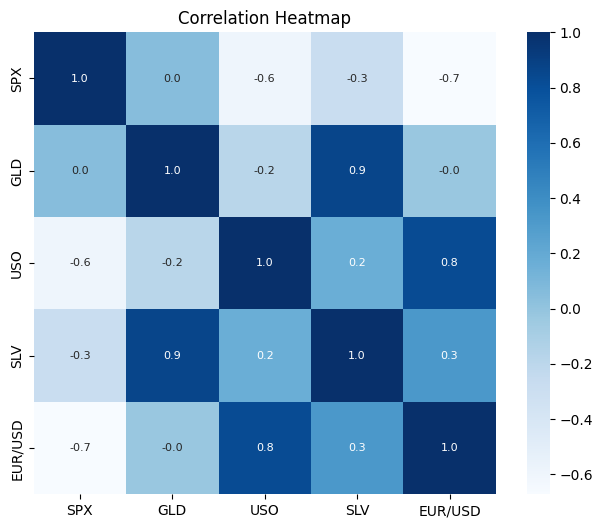

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

In [27]:
# CORRELATION VALUE OF GOLD
correlation['GLD']

,GLD
SPX,0.049345
GLD,1.000000
USO,-0.186360
SLV,0.866632
EUR/USD,-0.024375


/tmp/ipykernel_734/3854664301.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'], color='green')


<Axes: xlabel='GLD', ylabel='Density'>

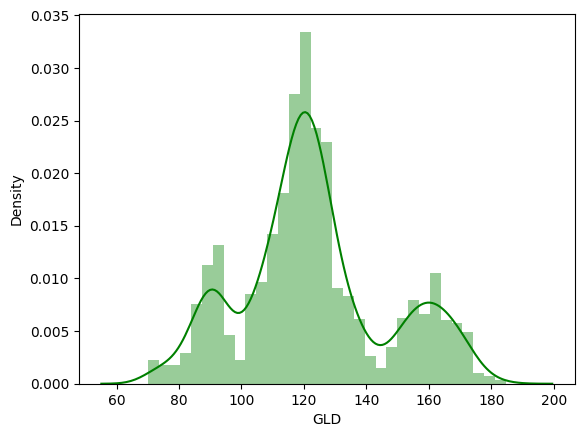

In [28]:
#checking the distribution of GLD price
sns.distplot(gold_data['GLD'], color='green')

Splitting the feature and target


In [29]:
X=gold_data.drop(['Date','GLD'],axis=1)
Y=gold_data['GLD']

In [31]:
Y

,GLD
0,84.860001
1,85.570000
2,85.129997
3,84.769997
4,86.779999
...,...
2285,124.589996
2286,124.330002
2287,125.180000
2288,124.489998


In [32]:
X

,SPX,USO,SLV,EUR/USD
0,1447.160034,78.470001,15.1800,1.471692
1,1447.160034,78.370003,15.2850,1.474491
2,1411.630005,77.309998,15.1670,1.475492
3,1416.180054,75.500000,15.0530,1.468299
4,1390.189941,76.059998,15.5900,1.557099
...,...,...,...,...
2285,2671.919922,14.060000,15.5100,1.186789
2286,2697.790039,14.370000,15.5300,1.184722
2287,2723.070068,14.410000,15.7400,1.191753
2288,2730.129883,14.380000,15.5600,1.193118


Splitting training and test data

In [33]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

Model Training
RandomForestRegressor

In [34]:
regressor=RandomForestRegressor(n_estimators=100)

In [35]:
#fit data
regressor.fit(X_train,Y_train)

RandomForestRegressor()

Model Evalution


In [37]:
#prediction on test data
test_data_prediction=regressor.predict(X_test)



In [38]:
print(test_data_prediction)

[122.69209936 130.0860028  127.51929971  96.52889721 119.15140059
 114.50259914 124.71030145 117.68989941 108.06230115  98.31439981
  95.75779941 168.1710982  148.91620152 116.25859994 170.78080212
  84.88569992 122.99009873 109.49519728 113.23210109 131.77630257
 124.28809873 113.65650049 116.04070062 108.64499965 108.51160146
 125.76979954 119.41999982 112.55289928 113.66390151 125.40969935
 146.08490187  89.50540019 167.68229983 113.74459961 108.58480085
 120.10060143 141.45539814 161.33700154 174.17369809 153.03250112
 119.34190106 113.4547004  121.39719936 113.74999957 122.04000033
 107.81150094  88.55799889 114.54619923 129.88250205 118.11120062
 103.76020003 129.89100182 107.15409841 160.46300376 131.43570044
 118.24349969 146.93500037 135.62090172  95.63120092 124.60900145
 115.10099905  86.2355005  104.229399   114.33860087  84.11529917
 122.33520062 116.56319919 113.64310194 165.2770024   92.44660027
  80.38940118 161.08180057 157.78870254 106.53309989 148.45430099
 109.74409

In [39]:
# R2 Error
error_score=metrics.r2_score(Y_test,test_data_prediction)
print("R2 Error: ",error_score)

R2 Error:  0.9893587791277719


Compare the actual and predicted value


In [40]:
Y_test=list(Y_test)

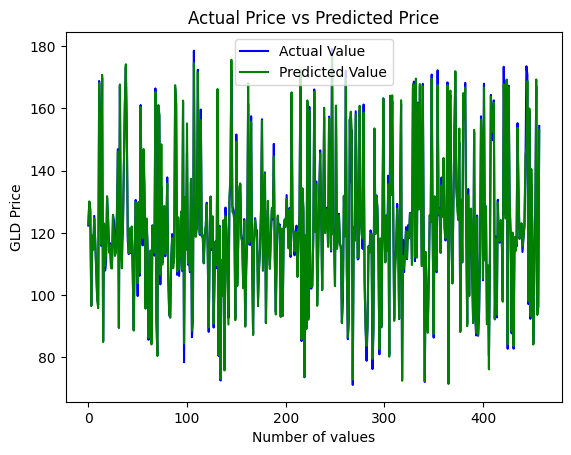

In [45]:
plt.plot(Y_test,color='blue',label='Actual Value')
plt.plot(test_data_prediction,color='green',label='Predicted Value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()